# Option Pricing

In [14]:
import csv
from io import StringIO
import requests
import yfinance as yf
import math

## Fetch Real Data

In [15]:
# 1) Fetch 1 year of AAPL daily data from yfinance
aapl = yf.Ticker("AAPL")
aapl_hist = aapl.history(period="1y", interval="1d")

# Spot price
S0 = float(aapl_hist["Close"].dropna().iloc[-1])

# Annualized volatility
log_returns = (aapl_hist["Close"] / aapl_hist["Close"].shift(1)).apply(math.log).dropna()
annualized_volatility = float(log_returns.std() * math.sqrt(252))

# 2) Fetch 3-month T-bill rate (TB3MS) from FRED
# No API key needed: use FRED public CSV endpoint

csv_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS"
resp = requests.get(csv_url, timeout=20)
resp.raise_for_status()
rows = list(csv.DictReader(StringIO(resp.text)))

tb3ms_value = None
for row in reversed(rows):
    value = row.get("TB3MS")
    if value not in (None, "", "."):
        tb3ms_value = float(value)
        break
if tb3ms_value is None:
    raise ValueError("No valid TB3MS value found in FRED CSV response.")
rf = tb3ms_value / 100.0

# 3) Fetch AAPL option chain from yfinance
# This creates a dictionary keyed by expiration date
option_chain = {}
for exp in aapl.options:
    chain = aapl.option_chain(exp)
    option_chain[exp] = {
        "calls": chain.calls.copy(),
        "puts": chain.puts.copy()
    }

print(f"AAPL history rows: {len(aapl_hist)}")
print(f"AAPL option expiries: {len(option_chain)}")
print(f"S0 (last AAPL close): {S0:.4f}")
print(f"rf (TB3MS as decimal): {rf:.6f}")

AAPL history rows: 252
AAPL option expiries: 24
S0 (last AAPL close): 272.3094
rf (TB3MS as decimal): 0.036100


## Set Parameters

In [16]:
# Parameters
T = 0.5  # 6 months in years
K = float(round(S0 * 1.02, 2))  # strike set 2% above spot
sigma = annualized_volatility

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.pricing import BlackScholes, MonteCarlo, BinomialTree, OptionParams

call_params = OptionParams(S=S0, K=K, T=T, r=rf, sigma=sigma, option_type="call")
put_params  = OptionParams(S=S0, K=K, T=T, r=rf, sigma=sigma, option_type="put")

print(f"S₀={S0:.2f}  K={K:.2f}  T={T}y  r={rf:.4f}  σ={sigma:.4f}")

S₀=272.31  K=277.76  T=0.5y  r=0.0361  σ=0.2342


## Black-Scholes — Closed-Form Analytical Pricing

Computes the exact price of European call and put options under the Black-Scholes assumptions (log-normal price process, constant volatility, no dividends). This is the reference benchmark: all numerical methods are validated against it.

In [18]:
bs = BlackScholes()
bs_call = bs.price(call_params)
bs_put  = bs.price(put_params)

print(f"Black-Scholes Call: {bs_call.price:.4f}")
print(f"Black-Scholes Put:  {bs_put.price:.4f}")

Black-Scholes Call: 17.7435
Black-Scholes Put:  18.2255


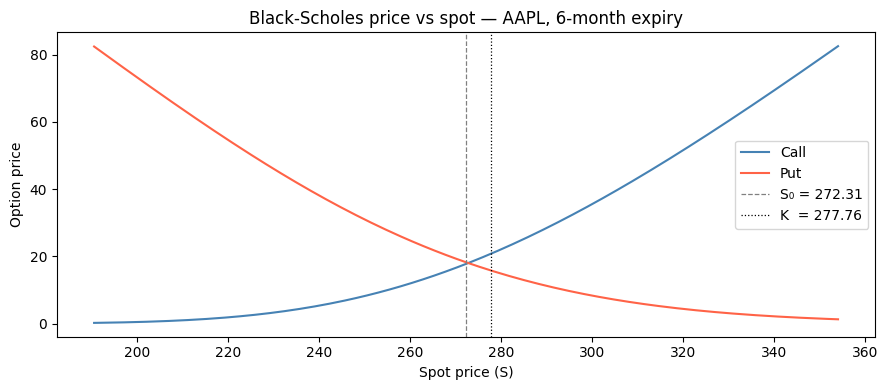

In [19]:
spot_range = np.linspace(S0 * 0.7, S0 * 1.3, 200)
bs_calls = [BlackScholes().price(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="call")).price for s in spot_range]
bs_puts  = [BlackScholes().price(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="put")).price  for s in spot_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spot_range, bs_calls, label="Call", color="steelblue")
ax.plot(spot_range, bs_puts,  label="Put",  color="tomato")
ax.axvline(S0, linestyle="--", color="gray",  linewidth=0.9, label=f"S₀ = {S0:.2f}")
ax.axvline(K,  linestyle=":",  color="black", linewidth=0.9, label=f"K  = {K:.2f}")
ax.set_xlabel("Spot price (S)")
ax.set_ylabel("Option price")
ax.set_title("Black-Scholes price vs spot — AAPL, 6-month expiry")
ax.legend()
plt.tight_layout()
plt.show()

## Monte Carlo — Stochastic Simulation

Simulates thousands of possible price paths for AAPL under the risk-neutral GBM measure and averages the discounted payoffs. Uses antithetic variates (each random draw is paired with its mirror) to reduce variance without increasing the number of paths.

In [20]:
mc = MonteCarlo(n_paths=50_000)
mc_call = mc.price(call_params)
mc_put  = mc.price(put_params)

print(f"Monte Carlo Call (50k paths): {mc_call.price:.4f}  |  vs BS: {mc_call.price - bs_call.price:+.4f}")
print(f"Monte Carlo Put  (50k paths): {mc_put.price:.4f}  |  vs BS: {mc_put.price - bs_put.price:+.4f}")

Monte Carlo Call (50k paths): 17.7488  |  vs BS: +0.0053
Monte Carlo Put  (50k paths): 18.2154  |  vs BS: -0.0101


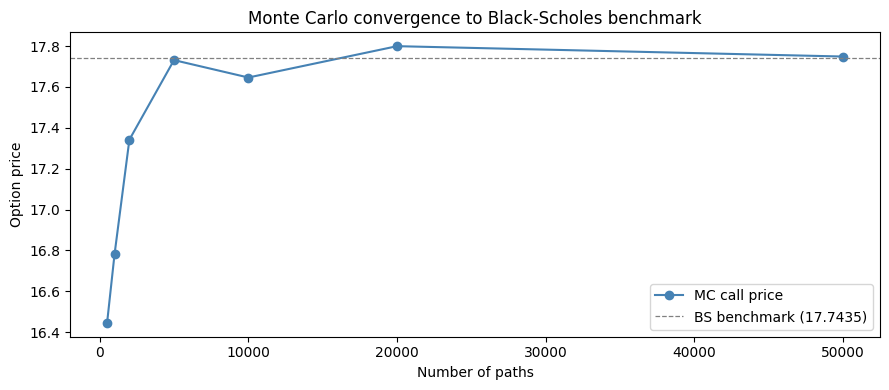

In [21]:
path_counts = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
mc_conv = [MonteCarlo(n_paths=n).price(call_params).price for n in path_counts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(path_counts, mc_conv, marker="o", color="steelblue", label="MC call price")
ax.axhline(bs_call.price, linestyle="--", color="gray", linewidth=0.9, label=f"BS benchmark ({bs_call.price:.4f})")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Option price")
ax.set_title("Monte Carlo convergence to Black-Scholes benchmark")
ax.legend()
plt.tight_layout()
plt.show()

## Binomial Tree — CRR Lattice

Builds a discrete recombining tree of possible stock prices (Cox-Ross-Rubinstein parameterisation) and solves for the option value by backward induction. Prices both European options (no early exercise) and American options (early exercise allowed at every node — relevant for puts).

In [22]:
bt_call_eur = BinomialTree(steps=500).price(call_params)
bt_put_eur  = BinomialTree(steps=500).price(put_params)
bt_put_amer = BinomialTree(steps=500, american=True).price(put_params)

print(f"Binomial Tree Call — European (500 steps): {bt_call_eur.price:.4f}  |  vs BS: {bt_call_eur.price - bs_call.price:+.4f}")
print(f"Binomial Tree Put  — European (500 steps): {bt_put_eur.price:.4f}  |  vs BS: {bt_put_eur.price - bs_put.price:+.4f}")
print(f"Binomial Tree Put  — American (500 steps): {bt_put_amer.price:.4f}  |  early exercise premium: {bt_put_amer.price - bt_put_eur.price:+.4f}")

Binomial Tree Call — European (500 steps): 17.7504  |  vs BS: +0.0068
Binomial Tree Put  — European (500 steps): 18.2324  |  vs BS: +0.0068
Binomial Tree Put  — American (500 steps): 18.7677  |  early exercise premium: +0.5354


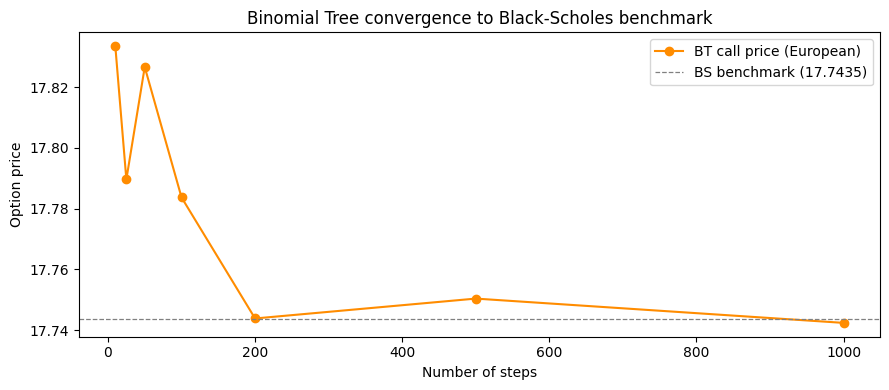

In [23]:
step_counts = [10, 25, 50, 100, 200, 500, 1000]
bt_conv = [BinomialTree(steps=n).price(call_params).price for n in step_counts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(step_counts, bt_conv, marker="o", color="darkorange", label="BT call price (European)")
ax.axhline(bs_call.price, linestyle="--", color="gray", linewidth=0.9, label=f"BS benchmark ({bs_call.price:.4f})")
ax.set_xlabel("Number of steps")
ax.set_ylabel("Option price")
ax.set_title("Binomial Tree convergence to Black-Scholes benchmark")
ax.legend()
plt.tight_layout()
plt.show()

## Method Comparison

In [25]:
labels      = ["Black-Scholes", "Monte Carlo\n(50k paths)", "Binomial Tree\n(500 steps)"]
call_prices = [bs_call.price, mc_call.price, bt_call_eur.price]
put_prices  = [bs_put.price,  mc_put.price,  bt_put_eur.price]

print(f"{'Method':<25} {'Call':>10} {'Put':>10} {'Call vs BS':>12} {'Put vs BS':>12}")
print("-" * 70)
for label, c, p in zip(["Black-Scholes", "Monte Carlo (50k)", "Binomial Tree (500)"], call_prices, put_prices):
    call_diff = f"{c - bs_call.price:+.4f}" if label != "Black-Scholes" else "—"
    put_diff  = f"{p - bs_put.price:+.4f}"  if label != "Black-Scholes" else "—"
    print(f"{label:<25} {c:>10.4f} {p:>10.4f} {call_diff:>12} {put_diff:>12}")

Method                          Call        Put   Call vs BS    Put vs BS
----------------------------------------------------------------------
Black-Scholes                17.7435    18.2255            —            —
Monte Carlo (50k)            17.7488    18.2154      +0.0053      -0.0101
Binomial Tree (500)          17.7504    18.2324      +0.0068      +0.0068
